### ***Name: Abdelrhman Mohamed Abdelhady Hodib ID : 2022513643***

## **L1 and L2 and DROPOUT** 

In [1]:
%pylab inline

import numpy as np
import pandas as pd
import imageio  # Import imageio
from sklearn.metrics import accuracy_score
import os  # Import the os module


from matplotlib import pyplot
import matplotlib.pyplot as plt  # You mentioned importing matplotlib, so including it here


import tensorflow as tf
import keras

from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# To stop potential randomness
seed = 128
rng = np.random.RandomState(seed)



## reading train file only
train = pd.read_csv('/kaggle/input/images/train.csv')
train.head()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


,filename,label
0,0.png,4
1,1.png,9
2,2.png,1
3,3.png,7
4,4.png,3


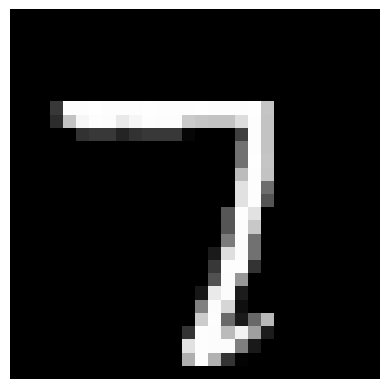

In [2]:
import random  # Import the random module
import imageio.v2 as imageio
# ... (previous code) ...

# Replace rng.choice with random.choice
img_name = random.choice(train.filename)

filepath = os.path.join('/kaggle/input/images/Images/train', img_name)

img =imageio.imread(filepath)


pylab.imshow(img, cmap='gray')
pylab.axis('off')
pylab.show()

In [3]:
#storing images in numpy arrays
temp = []
for img_name in train.filename:
 image_path = os.path.join('/kaggle/input/images/Images/train', img_name)
 img = imageio.imread(image_path)
 img = img.astype('float32')
 temp.append(img)
 
x_train = np.stack(temp)

x_train /= 255.0


y_train = keras.utils.np_utils.to_categorical(train.label.values)
# Split the data into training and testing sets


In [4]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(34300, 28, 28, 4)
(34300, 10)
(14700, 28, 28, 4)
(14700, 10)


In [5]:
x_train = x_train.reshape(x_train.shape[0], -1).astype('float32')
x_test = x_test.reshape(x_test.shape[0], -1).astype('float32')

In [6]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(34300, 3136)
(34300, 10)
(14700, 3136)
(14700, 10)


In [7]:
# import keras modules
from keras.models import Sequential
from keras.layers import Dense

# define vars
input_num_units = 3136
hidden1_num_units = 500
hidden2_num_units = 500
hidden3_num_units = 500
hidden4_num_units = 500
hidden5_num_units = 500
output_num_units = 10

epochs = 5
batch_size = 128

model = Sequential([
 Dense(units=hidden1_num_units, input_dim=input_num_units, activation='relu'),
 Dense(units=hidden2_num_units, input_dim=hidden1_num_units, activation='relu'),
 Dense(units=hidden3_num_units, input_dim=hidden2_num_units, activation='relu'),
 Dense(units=hidden4_num_units, input_dim=hidden3_num_units, activation='relu'),
 Dense(units=hidden5_num_units, input_dim=hidden4_num_units, activation='relu'),

Dense(units=output_num_units, input_dim=hidden5_num_units, activation='softmax'),
 ])

In [8]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

trained_model_5d = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))


Epoch 1/5
268/268 [==============================] - 5s 7ms/step - loss: 0.4511 - accuracy: 0.8526 - val_loss: 0.2561 - val_accuracy: 0.9171
Epoch 2/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1881 - accuracy: 0.9415 - val_loss: 0.1662 - val_accuracy: 0.9516
Epoch 3/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1536 - accuracy: 0.9515 - val_loss: 0.1342 - val_accuracy: 0.9603
Epoch 4/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1279 - accuracy: 0.9608 - val_loss: 0.1581 - val_accuracy: 0.9533
Epoch 5/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1092 - accuracy: 0.9659 - val_loss: 0.1552 - val_accuracy: 0.9560


In [9]:
from keras import regularizers

model2 = Sequential([
 Dense(units=hidden1_num_units, input_dim=input_num_units, activation='relu',
 kernel_regularizer=regularizers.l2(0.000001)),
 Dense(units=hidden2_num_units, input_dim=hidden1_num_units, activation='relu',
 kernel_regularizer=regularizers.l2(0.000001)),
 Dense(units=hidden3_num_units, input_dim=hidden2_num_units, activation='relu',
 kernel_regularizer=regularizers.l2(0.000001)),
 Dense(units=hidden4_num_units, input_dim=hidden3_num_units, activation='relu',
 kernel_regularizer=regularizers.l2(0.000001)),
 Dense(units=hidden5_num_units, input_dim=hidden4_num_units, activation='relu',
 kernel_regularizer=regularizers.l2(0.000001)),

Dense(units=output_num_units, input_dim=hidden5_num_units, activation='softmax'),
 ])

In [10]:
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

trained_model_5d = model2.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))


Epoch 1/5
268/268 [==============================] - 4s 7ms/step - loss: 0.4485 - accuracy: 0.8554 - val_loss: 0.2408 - val_accuracy: 0.9209
Epoch 2/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1988 - accuracy: 0.9396 - val_loss: 0.1833 - val_accuracy: 0.9467
Epoch 3/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1595 - accuracy: 0.9508 - val_loss: 0.1624 - val_accuracy: 0.9499
Epoch 4/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1231 - accuracy: 0.9620 - val_loss: 0.1487 - val_accuracy: 0.9567
Epoch 5/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1140 - accuracy: 0.9645 - val_loss: 0.1402 - val_accuracy: 0.9584


In [11]:
## l1

model3 = Sequential([
 Dense(units=hidden1_num_units, input_dim=input_num_units, activation='relu',
 kernel_regularizer=regularizers.l1(0.0001)),
 Dense(units=hidden2_num_units, input_dim=hidden1_num_units, activation='relu',
 kernel_regularizer=regularizers.l1(0.0001)),
 Dense(units=hidden3_num_units, input_dim=hidden2_num_units, activation='relu',
 kernel_regularizer=regularizers.l1(0.0001)),
 Dense(units=hidden4_num_units, input_dim=hidden3_num_units, activation='relu',
 kernel_regularizer=regularizers.l1(0.0001)),
 Dense(units=hidden5_num_units, input_dim=hidden4_num_units, activation='relu',
 kernel_regularizer=regularizers.l1(0.0001)),

Dense(units=output_num_units, input_dim=hidden5_num_units, activation='softmax'),
 ])

In [12]:
model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
trained_model_5d = model3.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

Epoch 1/5
268/268 [==============================] - 4s 7ms/step - loss: 2.9252 - accuracy: 0.8451 - val_loss: 1.7410 - val_accuracy: 0.9139
Epoch 2/5
268/268 [==============================] - 1s 5ms/step - loss: 1.4431 - accuracy: 0.9223 - val_loss: 1.2020 - val_accuracy: 0.9327
Epoch 3/5
268/268 [==============================] - 1s 5ms/step - loss: 1.0780 - accuracy: 0.9308 - val_loss: 0.9509 - val_accuracy: 0.9384
Epoch 4/5
268/268 [==============================] - 1s 5ms/step - loss: 0.8310 - accuracy: 0.9443 - val_loss: 0.7344 - val_accuracy: 0.9478
Epoch 5/5
268/268 [==============================] - 1s 5ms/step - loss: 0.6600 - accuracy: 0.9510 - val_loss: 0.6023 - val_accuracy: 0.9545


In [13]:
## dropout

from keras.layers.core import Dropout
model4 = Sequential([
 Dense(units=hidden1_num_units, input_dim=input_num_units, activation='relu'),
 Dropout(0.25),
 Dense(units=hidden2_num_units, input_dim=hidden1_num_units, activation='relu'),
 Dropout(0.25),
 Dense(units=hidden3_num_units, input_dim=hidden2_num_units, activation='relu'),
 Dropout(0.25),
 Dense(units=hidden4_num_units, input_dim=hidden3_num_units, activation='relu'),
 Dropout(0.25),
 Dense(units=hidden5_num_units, input_dim=hidden4_num_units, activation='relu'),
 Dropout(0.25),

Dense(units=output_num_units, input_dim=hidden5_num_units, activation='softmax'),
 ])

In [14]:
model4.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
trained_model_5d = model4.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))
## The model with dropout 

Epoch 1/5
268/268 [==============================] - 4s 8ms/step - loss: 0.7032 - accuracy: 0.7671 - val_loss: 0.2684 - val_accuracy: 0.9212
Epoch 2/5
268/268 [==============================] - 1s 6ms/step - loss: 0.3670 - accuracy: 0.8892 - val_loss: 0.2290 - val_accuracy: 0.9334
Epoch 3/5
268/268 [==============================] - 2s 6ms/step - loss: 0.2977 - accuracy: 0.9114 - val_loss: 0.2030 - val_accuracy: 0.9412
Epoch 4/5
268/268 [==============================] - 2s 6ms/step - loss: 0.2784 - accuracy: 0.9178 - val_loss: 0.2192 - val_accuracy: 0.9390
Epoch 5/5
268/268 [==============================] - 1s 6ms/step - loss: 0.2491 - accuracy: 0.9257 - val_loss: 0.1766 - val_accuracy: 0.9505


## **Early stopping**

In [15]:
'''
So Here we will import the Earlystopping function from keras.callbacks library 

then we will give it the important parameters like the (monitor= val_loss) that tells us that

we will stop when val_loss increase , (patience = 2) that tells us that i won't improve the training

unless that 2 epochs ended. And (restore_best_weights=True) that returns the best weights after stopping 
'''
early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=0,          # We will set it to 0
    restore_best_weights=True  
)


In [16]:
model5 = Sequential([
 Dense(units=hidden1_num_units, input_dim=input_num_units, activation='relu'),
 Dense(units=hidden2_num_units, input_dim=hidden1_num_units, activation='relu'),
 Dense(units=hidden3_num_units, input_dim=hidden2_num_units, activation='relu'),
 Dense(units=hidden4_num_units, input_dim=hidden3_num_units, activation='relu'),
 Dense(units=hidden5_num_units, input_dim=hidden4_num_units, activation='relu'),

Dense(units=output_num_units, input_dim=hidden5_num_units, activation='softmax'),
 ])

In [17]:
'''
So Here after we applied the early stopping in training the model 5, We deduced that the training loss and accuracy

were better than that in model 4 ( Model with dropout ) after 5 epochs.
'''

model5.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

trained_model_5d = model5.fit(x_train,y_train,epochs=epochs,batch_size=batch_size,validation_data=(x_test, y_test),callbacks=[early_stopping])

Epoch 1/5
268/268 [==============================] - 4s 7ms/step - loss: 0.4320 - accuracy: 0.8594 - val_loss: 0.2322 - val_accuracy: 0.9303
Epoch 2/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1934 - accuracy: 0.9391 - val_loss: 0.1787 - val_accuracy: 0.9459
Epoch 3/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1446 - accuracy: 0.9550 - val_loss: 0.1513 - val_accuracy: 0.9556
Epoch 4/5
268/268 [==============================] - 1s 5ms/step - loss: 0.1306 - accuracy: 0.9595 - val_loss: 0.1561 - val_accuracy: 0.9518


In [18]:
'''
So here We will compare between the evaluation of model with dropout and the model with early stopping on the test set,

we will find that the loss and accuracy of early stopping model are better.
'''
# Evaluate Model 4 (the model with dropout)
test_loss, test_accuracy = model4.evaluate(x_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

460/460 [==============================] - 1s 2ms/step - loss: 0.1766 - accuracy: 0.9505
Test Loss: 0.1766
Test Accuracy: 0.9505


In [19]:
# Evaluate the model 5 (Early stopping)
test_loss, test_accuracy = model5.evaluate(x_test, y_test)


print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

460/460 [==============================] - 1s 2ms/step - loss: 0.1513 - accuracy: 0.9556
Test Loss: 0.1513
Test Accuracy: 0.9556


## **Let's Try Data Augmentation**


In [20]:
model6 = keras.Sequential([
    keras.layers.Input(shape=(56, 56, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  
])


In [21]:
'''
So here we will use ImageDataGenerator to choose the specs of the photos that will be generated, Like that

we will rotate images by 40 degree or doing shear transformation or vertical flipping,etc. 

Before fitting the train data, We will reshape it to 4 dimensions to be suitable for fitting

Then we will fit the data generator on the training data to increase the size of data .
'''

datagen = ImageDataGenerator(
    rotation_range=40,      # Rotate images by up to 40 degrees
    width_shift_range=0.5,  # Shift width by up to 50%
    height_shift_range=0.1, # Shift height by up to 10%
    shear_range=0.3,       # Shear transformation
    zoom_range=0.22,         # Zoom in/out by up to 22%
    horizontal_flip=False,   # Flip images horizontally
    vertical_flip=True,     # Flip images vertically
)
x_test = x_test.reshape(-1, 56, 56, 1)
x_train = x_train.reshape(-1, 56, 56, 1)
datagen.fit(x_train)



In [25]:

model6.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
trained_model_5d= model6.fit(x_train,y_train,batch_size=batch_size,epochs=epochs,validation_data=(x_test, y_test))


Epoch 1/5
268/268 [==============================] - 2s 6ms/step - loss: 0.1633 - accuracy: 0.9515 - val_loss: 0.1666 - val_accuracy: 0.9525
Epoch 2/5
268/268 [==============================] - 1s 4ms/step - loss: 0.1392 - accuracy: 0.9577 - val_loss: 0.1622 - val_accuracy: 0.9527
Epoch 3/5
268/268 [==============================] - 1s 4ms/step - loss: 0.1207 - accuracy: 0.9641 - val_loss: 0.1713 - val_accuracy: 0.9502
Epoch 4/5
268/268 [==============================] - 1s 4ms/step - loss: 0.1132 - accuracy: 0.9647 - val_loss: 0.1409 - val_accuracy: 0.9590
Epoch 5/5
268/268 [==============================] - 1s 4ms/step - loss: 0.1006 - accuracy: 0.9682 - val_loss: 0.1443 - val_accuracy: 0.9572


In [26]:
"""
So when we evaluate the model we will find that loss and accuracy of that model (model with data augmentation ) are better than

that of the model with dropout . 
"""

# Evaluate the model 6 (Data augmentation)
test_loss, test_accuracy = model6.evaluate(x_test, y_test)


print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

460/460 [==============================] - 1s 2ms/step - loss: 0.1443 - accuracy: 0.9572
Test Loss: 0.1443
Test Accuracy: 0.9572
